# Scenario-Based Cyber Risk Analysis

This notebook compares financial risk across different cyber scenarios:

- Ransomware
- Cloud Data Breach
- AI Misuse

Goal:
Understand which scenarios drive the highest financial exposure and tail risk.

In [1]:
# ======================
# 02 — SCENARIO ANALYSIS
# ======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# ======================
# CONFIGURATION
# ======================

SIMULATIONS = 10000
LOSS_MEAN = 14.5
LOSS_SIGMA = 0.7

In [3]:
# ======================
# RISK ENGINE
# ======================

def simulate_ale(tef_range, loss_mean, loss_sigma, n=10000):
    tef = np.random.triangular(*tef_range, n)
    loss = np.random.lognormal(loss_mean, loss_sigma, n)
    return tef * loss

In [4]:
# ======================
# SCENARIOS
# ======================

scenarios = {
    "Ransomware": (1, 3, 6),
    "Cloud Breach": (0.5, 1, 2),
    "AI Misuse": (2, 4, 8),
}

In [5]:
# ======================
# RUN SIMULATIONS
# ======================

results = {}

for name, tef_range in scenarios.items():
    results[name] = simulate_ale(
        tef_range,
        LOSS_MEAN,
        LOSS_SIGMA,
        SIMULATIONS
    )

In [6]:
# ======================
# SUMMARY TABLE
# ======================

summary = {}

for name, ale in results.items():
    summary[name] = {
        "Median": np.percentile(ale, 50),
        "90th": np.percentile(ale, 90),
        "95th": np.percentile(ale, 95),
    }

df = pd.DataFrame(summary)
print(df)

          Ransomware  Cloud Breach     AI Misuse
Median  6.304052e+06  2.211522e+06  9.033455e+06
90th    1.687177e+07  5.755706e+06  2.307029e+07
95th    2.223618e+07  7.688212e+06  3.035058e+07


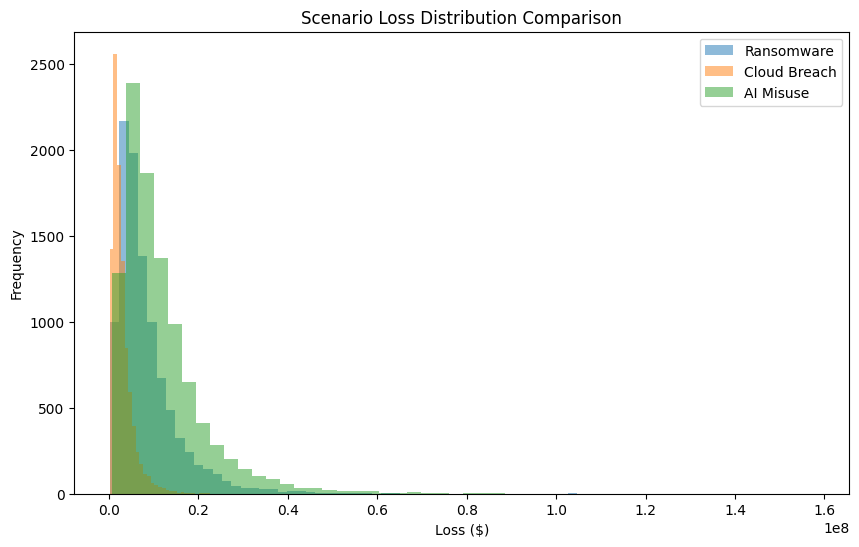

In [8]:
# ======================
# VISUALIZATION
# ======================

plt.figure(figsize=(10,6))

for name, ale in results.items():
    plt.hist(ale, bins=50, alpha=0.5, label=name)

plt.legend()
plt.title("Scenario Loss Distribution Comparison")
plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.show()

In [9]:
print("\n=== FINAL SUMMARY: SCENARIO COMPARISON ===")
print(df)


=== FINAL SUMMARY: SCENARIO COMPARISON ===
          Ransomware  Cloud Breach     AI Misuse
Median  6.304052e+06  2.211522e+06  9.033455e+06
90th    1.687177e+07  5.755706e+06  2.307029e+07
95th    2.223618e+07  7.688212e+06  3.035058e+07
